## <b><u>Infrared.city-1</u>: Tree detection</b>
<i>created by Nina Salnikow</i>
### <b>Introduction</b>

As urban areas are expanding and global temperatures rise due to climate change, being able to understand how trees can help cool cities has become increasingly important. Furthermore, trees reduce the risk of flooding in cities and promote health and wellbeing. Our project aims at taking the first step in the direction of better tree coverage in urban areas by creating a model which is able to predict tree locations using satellite imagery of densely populated areas. <i><u>In this notebook we will fetch and prepear <b>additional data</u></b>:</i>

### <b>Notebook structure 3</b>

&nbsp;&nbsp;&nbsp;<b>1. Fetching more tree catastratee data</b><br>
&nbsp;&nbsp;&nbsp;<b>2. Cleaning tree catastratee data</b><br>
&nbsp;&nbsp;&nbsp;<b>3. Saving cleaned tree catastratee data</b><br>

&nbsp;&nbsp;&nbsp;<b>4. Fetching more osm data</b><br>
&nbsp;&nbsp;&nbsp;<b>5. Cleaning osm data</b><br>
&nbsp;&nbsp;&nbsp;<b>6. Saving cleaned osm data</b><br>

&nbsp;&nbsp;&nbsp;<b>7. Documentation of fetching more satellite image data</b><br>
&nbsp;&nbsp;&nbsp;<b>8. Documentation of additional viennese context data</b><br>

### <b><u>New</u> shared folder structure</b>
/home/jovyan/ideas-dslab-group1-shared/<br>
├── <u>raw data/</u> (backup)<br>
│&ensp;&ensp;&ensp;      ├── baumkataster data/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── vienna_baumkataster<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── paris_baumkataster/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── prag_baumkataster/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── hamburger_baumkataster/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── <b>innsburck_baumkataster/</b><br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   └── <b>linz_baumkataster/</b><br>
│&ensp;&ensp;&ensp;   ├── <s>sentinel data/</s> -> already cleaned<br>
│&ensp;&ensp;&ensp;   ├── osm data/<br>
│&ensp;&ensp;&ensp;   └── <b>vienna context data/</b><br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── <b>vienna_land_use_data.json</b><br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── <b>vienna_green_space_data.json</b><br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp; └── <b>vienna_multi_map_data.gpkg</b><br>
└── <u>cleaned data/</u><br>
&ensp;&ensp;&ensp; &ensp;├── baumkataster data/ <b>-> added Innsbruck & Linz data</b><br>
&ensp;&ensp;&ensp;&ensp;          ├── sentinel data/ <b>-> added Innsbruck & Linz 2025 images</b> <br>
&ensp;&ensp;&ensp;&ensp;   ├── osm data/ <b>-> added Innsbruck & Linz data</b><br>
&ensp;&ensp;&ensp;&ensp;   └── <b>vienna context data/</b>
<br>

##  <b>1. Fetching <u>more</u> data</b>


<u>Innsbruck</u>

- <b><a href="https://www.data.gv.at/datasets/df4cc7ae-ead7-49aa-bcb8-b018f169162d?locale=en">Innsbruck Baumkataster(cadastre)</a></b> <i>Official City of Innsbruck tree cadastre with tree locations</i><br>

- <b><a href="https://download.geofabrik.de/europe">OpenStreetMap Urban Features of Innsbruck aka. Austria</a></b> <i>OpenStreetMap vector data including urban context</i><br>

<u>Linz</u>

- <b><a href="https://www.data.gv.at/datasets/f660cf3f-afa9-4816-aafb-0098a36ca57d?locale=de">Linz Baumkataster(cadastre)</a></b> <i>Official City of Linz tree cadastre with tree locations</i><br>

- <b><a href="https://download.geofabrik.de/europe">OpenStreetMap Urban Features of Linz aka. Austria</a></b> <i>OpenStreetMap vector data including urban context</i><br>

<u>More satellite image data for Innsbruck and Linz</u>

- <b><a href="https://code.earthengine.google.com/">Sentinel-2 Satellite Images</a></b> <i>Multispectral satellite imagery including 10 m resolution bands (GeoTIFF)</i><br>

<u>More viennese context data for ML model</u>

- <b><a href="https://www.data.gv.at/datasets/9e1ad9a0-ff89-3ac2-b4ac-d87f3a2c6554?locale=de">RNK Land Use Data</a></b><i>  Official Vienna land-use polygons</i>

- <b><a href="https://www.data.gv.at/datasets/d0145df8-7f6d-46e1-9bc6-ee7897054104?locale=de">Public Green Space Data</a></b><i>  Official polygons of <u>publicly</u> accessible green areas in Vienna</i>

- <b><a href="https://www.data.gv.at/datasets/7cf0da04-1f77-4321-929e-78172c74aa0b?locale=de">Vienna Multi-Purpose Map (Vector Data)</a></b><i> Detailed urban surface and infrastructure data</i>

## Innsbruck Baumkataster

<i>Source from 2021</i>: https://www.data.gv.at/datasets/df4cc7ae-ead7-49aa-bcb8-b018f169162d?locale=en<br>
<i>Source from 2025</i>: https://www.data.gv.at/datasets/920056c2-fd27-4616-8758-d55d658d2c04?locale=en

<blockquote>The 2025 data redirects to a map totaling "13600 tree", which matches the 13656 trees in the 2021 dataset. Since the counts are identical, it indicates the database has not been updated. <br>Therefore, we will use the 2021 version as it provides a full, detailed cadastre for our project</blockquote>

In [1]:
import pandas as pd

#Columns: OBJECTID: laufende Nummer; Anlage: Name der Grünanlage; Baumnummer; Gattung_Dt: Gattung Deutsch; Gattung_Lat: Gattung Latein; Pflanzdatum; X: Koordinate GK-M28; Y: Koordinate GK-M28; Lon: geogr. Länge WGS84; Lat: geogr. Breite <- cuttet :(
innsbruck = pd.read_excel("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/innsbruck_baumkataster.xlsx")
print(innsbruck.head())
print(len(innsbruck))

   OBJECTID                       Anlage  Baumnummer   Gattung_Dt  \
0         1  Kaiser-Franz-Joseph-StraÃŸe          19  Winterlinde   
1         2  Kaiser-Franz-Joseph-StraÃŸe          23  Winterlinde   
2         3  Kaiser-Franz-Joseph-StraÃŸe          26  Winterlinde   
3         4  Kaiser-Franz-Joseph-StraÃŸe          27  Winterlinde   
4         5  Kaiser-Franz-Joseph-StraÃŸe          29  Winterlinde   

     Gattung_Lat Pflanzdatum         X          Y        Lon        Lat  
0  Tilia cordata         NaT  81251.12  238102.32  11.406882  47.276757  
1  Tilia cordata         NaT  81223.86  238073.65  11.406517  47.276503  
2  Tilia cordata         NaT  81203.53  238052.22  11.406244  47.276313  
3  Tilia cordata         NaT  81196.58  238044.95  11.406151  47.276248  
4  Tilia cordata         NaT  81182.83  238030.83  11.405967  47.276123  
13656


## Linz Baumkataster

<i>Source 2026</i>: https://www.data.gv.at/datasets/f660cf3f-afa9-4816-aafb-0098a36ca57d?locale=en

<u><i><b>Note:</b> Delimeter is ;</i></u>

<blockquote>Linz has an current dataset from 28. Januar 2026 with 26866 tees:</blockquote>

In [3]:
#Columns: Gattung, Art, Sorte, Höhe (Meter), Schirmdurchmesser (Meter), Stammumfang (Zentimeter), Typ (L=Laubbaum, N=Nadelbaum), XPos, YPos (Landeskoordinatensystem für Zentral-Österreich), lon, lat (GPS-Koordinaten EPSG:4326 WGS84)
linz = pd.read_csv("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/linz_baumkataster.csv", sep=';')
print(linz.head())
print(len(linz))

  Flaeche  Gattung      Art Sorte    NameDeutsch  Hoehe  Schirmdurchmesser  \
0    1127   Betula  pendula     -     Weiß-Birke   16.0                8.0   
1    7290  Juglans    regia     -        Walnuss    4.0                4.0   
2    1100   Prunus    avium     -  Vogel-Kirsche   17.0                8.0   
3     174    Tilia  cordata     -   Winter-Linde    7.0                4.0   
4     634   Betula  pendula     -     Weiß-Birke   15.0                5.0   

   Stammumfang Typ   XPos    YPos        lon        lat BaumNr  DatumExport  
0        200.0   L  68728  353883  14.259250  48.319455    005     20260101  
1         55.0   L  72065  354586  14.304350  48.325411    070     20260101  
2        105.0   L  70052  351422  14.276693  48.297183    342     20260101  
3         39.0   L  71416  349005  14.294660  48.275297    017     20260101  
4        154.0   L  72794  355372  14.314323  48.332396    064     20260101  
26866


## <b>2. Cleaning tree cadastre data</b>

<b>We will now prepare our datasets from Linz and Innsbruck:</b>

## Checking duplicates

In [4]:
innsbruck.duplicated().any()

np.False_

In [5]:
linz.duplicated().any()

np.False_

<blockquote>Good, we do not have any duplicates.</blockquote> 

## Dropping irrelevant columns

After manual inspections, I will drop following columns, as they are not need for the ML modelling:

In [6]:
print(innsbruck.columns)
print(linz.columns)

Index(['OBJECTID', 'Anlage', 'Baumnummer', 'Gattung_Dt', 'Gattung_Lat',
       'Pflanzdatum', 'X', 'Y', 'Lon', 'Lat'],
      dtype='str')
Index(['Flaeche', 'Gattung', 'Art', 'Sorte', 'NameDeutsch', 'Hoehe',
       'Schirmdurchmesser', 'Stammumfang', 'Typ', 'XPos', 'YPos', 'lon', 'lat',
       'BaumNr', 'DatumExport'],
      dtype='str')


In [7]:
innsbruck = innsbruck[["Lon","Lat", "Gattung_Lat"]] #bezirk is not that useful, labeled data, i will drop it too
innsbruck.head(1)

,Lon,Lat,Gattung_Lat
0,11.406882,47.276757,Tilia cordata


In [8]:
linz = linz[["lon","lat","Gattung", "Art", "Typ", "Hoehe" , "Schirmdurchmesser","Stammumfang"]] #bezirk is not that useful, labeled data, i will drop it too
# Faeche is likely an ID, whcih we will not need for our analysis
linz.head(1)

,lon,lat,Gattung,Art,Typ,Hoehe,Schirmdurchmesser,Stammumfang
0,14.25925,48.319455,Betula,pendula,L,16.0,8.0,200.0


## Unifying the columns

Innsbruck is already tidy, but Linz needs some unifying.<br>
We have to combine the columns <u>"Gattung" and "Art"</u> and rename the columns for tidiness.

In [9]:
#using pop from algodat soberning class :o -> like why not
linz["species_latin"] = (linz.pop("Gattung").fillna("") + " " + linz.pop("Art").fillna("")).str.strip()
#if both are missing we fill them with "unknown"
linz["species_latin"] = linz["species_latin"].replace("", "unknown") 
print(linz.head(5))

         lon        lat Typ  Hoehe  Schirmdurchmesser  Stammumfang  \
0  14.259250  48.319455   L   16.0                8.0        200.0   
1  14.304350  48.325411   L    4.0                4.0         55.0   
2  14.276693  48.297183   L   17.0                8.0        105.0   
3  14.294660  48.275297   L    7.0                4.0         39.0   
4  14.314323  48.332396   L   15.0                5.0        154.0   

    species_latin  
0  Betula pendula  
1   Juglans regia  
2    Prunus avium  
3   Tilia cordata  
4  Betula pendula  


In [10]:
#important = Typ (L=Laubbaum, N=Nadelbaum) # i kept it just in case, we still can drop it in the ml part
linz = linz.rename(columns={"lat": "latitude","lon": "longitude", "Hoehe": "height", "Stammumfang": "circumference","Schirmdurchmesser": "crown_diameter", "Typ":"type_of_tree"})
innsbruck = innsbruck.rename(columns={"Lat": "latitude","Lon": "longitude","Gattung_Lat": "species_latin"})

In [11]:
#add a city feature
innsbruck['city']= "innsbruck"
linz['city']= "linz"

In [12]:
print(innsbruck.head(1))

   longitude   latitude  species_latin       city
0  11.406882  47.276757  Tilia cordata  innsbruck


In [13]:
print(linz.head(1))
#Höhe (Meter), Schirmdurchmesser (Meter), Stammumfang (Zentimeter)

   longitude   latitude type_of_tree  height  crown_diameter  circumference  \
0   14.25925  48.319455            L    16.0             8.0          200.0   

    species_latin  city  
0  Betula pendula  linz  


<blockquote>Now let us check if we still got missings.</blockquote>

## Checking missings

In [14]:
innsbruck.isnull().sum() #nice no missings

longitude        0
latitude         0
species_latin    0
city             0
dtype: int64

In [15]:
linz.isnull().sum() 

longitude          0
latitude           0
type_of_tree       0
height             2
crown_diameter    47
circumference     56
species_latin      0
city               0
dtype: int64

# Handling missings
We still have missings in height, crown_diameter and circumference data in linz dataframe. <br>
By just dropping them we would lose valuable data in other columns.<br>

In [16]:
linz.groupby("species_latin")["circumference"].apply(lambda x: x.isnull().mean())

species_latin
Abies  alba                      0.0
Abies borisii-regis              0.0
Abies cephalonica                0.0
Abies concolor                   0.0
Abies homolepis                  0.0
                                ... 
Ulmus sp.                        0.0
Zelkova carpinifolia             0.0
Zelkova serrata                  0.0
Zelkova sp.                      0.0
nicht bestimmt nicht bestimmt    0.0
Name: circumference, Length: 374, dtype: float64

<blockquote>The missing values are likely Missing At Random (MAR). <br>Moreover, we only have at maximum <u>4% missing rows</u> (=105/26866).<br>
Therefore, we group by species to calculate the median to fill up the missings.
</blockquote>

In [17]:
#https://stackoverflow.com/questions/72497624/how-do-i-df-fillna-with-category-median-values
for col in ["height","crown_diameter", "circumference"]:
    linz[col] = linz.groupby("species_latin")[col].transform(lambda x: x.fillna(x.median()))
    linz[col] = linz[col].fillna(linz[col].median()) #fallback falls eine row nur missings hat :o 
linz.isnull().sum()

longitude         0
latitude          0
type_of_tree      0
height            0
crown_diameter    0
circumference     0
species_latin     0
city              0
dtype: int64

## Converting Datatypes

<blockquote> The datatype are already consistent, as all numeric columns are <code>float64</code>.</blockquote>

In [18]:
innsbruck.info()

<class 'pandas.DataFrame'>
RangeIndex: 13656 entries, 0 to 13655
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   longitude      13656 non-null  float64
 1   latitude       13656 non-null  float64
 2   species_latin  13656 non-null  str    
 3   city           13656 non-null  str    
dtypes: float64(2), str(2)
memory usage: 819.7 KB


In [19]:
linz.info()

<class 'pandas.DataFrame'>
RangeIndex: 26866 entries, 0 to 26865
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   longitude       26866 non-null  float64
 1   latitude        26866 non-null  float64
 2   type_of_tree    26866 non-null  str    
 3   height          26866 non-null  float64
 4   crown_diameter  26866 non-null  float64
 5   circumference   26866 non-null  float64
 6   species_latin   26866 non-null  str    
 7   city            26866 non-null  str    
dtypes: float64(5), str(3)
memory usage: 2.2 MB


In [20]:
#linz:Columns: Gattung, Art, Sorte, Höhe (Meter), Schirmdurchmesser (Meter), Stammumfang (Zentimeter), Typ (L=Laubbaum, N=Nadelbaum), XPos, YPos (Landeskoordinatensystem für Zentral-Österreich), lon, lat (GPS-Koordinaten EPSG:4326 WGS84)
#innsbruck:Columns: OBJECTID: laufende Nummer; Anlage: Name der Grünanlage; Baumnummer; Gattung_Dt: Gattung Deutsch; Gattung_Lat: Gattung Latein; Pflanzdatum; X: Koordinate GK-M28; Y: Koordinate GK-M28; Lon: geogr. Länge WGS84; Lat: geogr. Breite

### <b>3. Overview and saving tree catastratee data</b>

## <center> Overview</center>

| Column | Meaning  | Unit |
| -------------- | --------------------------------------------- | ----------- |
| latitude   | geographic latitude (WGS84 / EPSG:4326)   | degree |
| longitude    | geographic longitude (WGS84 / EPSG:4326)   | degrees     |
| species_latin  | latin tree species or genus name | /    |
| height    | tree height     | meters (linz)  |
| circumference  | trunk circumference           | centimeters (linz) |
| crown_diameter | width of the tree crown      | meters (linz)      |
| type_of_tree   | tree classification code    | /   |
| city   | source city identifier   | /  |



### Notes

- Missing species information was replaced with the placeholder string <code>"unknown"</code>.<br>

- <i><b>Linz</b> contains the attribute <code>type_of_tree</code> with values such as:</i><br>
&nbsp;&nbsp;&nbsp;- <u>L</u> = deciduous tree (<i>Laubbaum</i>)<br>
&nbsp;&nbsp;&nbsp;- <u>N</u> = coniferous tree (<i>Nadelbaum</i>)<br><br>


<blockquote>
<b>A EDA notebook from my colleague will follow to provide statistical proof and further data cleaning.</b>
</blockquote>

### Saving data as Parquets

In [21]:
#innsbruck.head(5)
#linz.head(5)

#https://geopandas.org/en/stable/docs/user_guide/io.html
innsbruck.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/innsbruck.parquet")
linz.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/linz.parquet")

## <b>4. Fetching osm data</b>

We already got the Austrian OSM data, we just have to clip to the cities Innsbruck and Linz coordinates:

In [26]:
!pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 67.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 259.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 154.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]


In [27]:
import pandas as pd # gotta load it again as I wont reload the first part of this code
import geopandas as gpd

#calculate poi or aoi for the rectangle box input
df_linz = pd.read_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/linz.parquet") #zwischenstep, weil es kein geometry column hat
linz = list(gpd.GeoDataFrame(df_linz, geometry=gpd.points_from_xy(df_linz["longitude"], df_linz["latitude"]), crs="EPSG:4326").total_bounds)

df_innsbruck = pd.read_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/innsbruck.parquet") #zwischenstep, weil es kein geometry column hat
innsbruck =list(gpd.GeoDataFrame(df_innsbruck, geometry=gpd.points_from_xy(df_innsbruck["longitude"], df_innsbruck["latitude"]), crs="EPSG:4326").total_bounds)

print("linz =", linz)
print("innsbruck =", innsbruck)

linz = [np.float64(14.24760863138677), np.float64(48.21615521360738), np.float64(14.39127985489068), np.float64(48.35262551106651)]
innsbruck = [np.float64(11.324835138), np.float64(47.224833655), np.float64(11.451947919), np.float64(47.289498865)]


In [30]:
#linz
roads_linz = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_roads_free").to_crs(4326)
roads_linz = roads_linz.cx[linz[0]:linz[2], linz[1]:linz[3]] #here we clip to the location using baumkataster total bound points
buildings_linz = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_buildings_a_free").to_crs(4326)
buildings_linz = buildings_linz.cx[linz[0]:linz[2], linz[1]:linz[3]]
landuse_linz = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_landuse_a_free").to_crs(4326)
landuse_linz = landuse_linz.cx[linz[0]:linz[2], linz[1]:linz[3]]
water_linz = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_water_a_free").to_crs(4326)
water_linz= water_linz.cx[linz[0]:linz[2], linz[1]:linz[3]]

roads_linz.head()
buildings_linz.head()
landuse_linz.head()
water_linz.head()

,osm_id,code,fclass,name,geometry
35,3870488,8200,water,Großer Weikerlsee,"MULTIPOLYGON (((14.36548 48.26583, 14.3655 48...."
38,3870527,8200,water,Pichlinger See,"MULTIPOLYGON (((14.3762 48.2367, 14.37624 48.2..."
51,3870639,8200,water,Pleschinger See,"MULTIPOLYGON (((14.32979 48.32002, 14.32981 48..."
65,4612157,8202,riverbank,,"MULTIPOLYGON (((14.19211 48.32869, 14.19261 48..."
168,8043899,8200,water,Voestalpine Werkshafen,"MULTIPOLYGON (((14.3274 48.28032, 14.32745 48...."


In [31]:
#innsbruck
roads_innsbruck = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_roads_free").to_crs(4326)
roads_innsbruck = roads_innsbruck.cx[innsbruck[0]:innsbruck[2], innsbruck[1]:innsbruck[3]] #here we clip to the location using baumkataster data
buildings_innsbruck = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_buildings_a_free").to_crs(4326)
buildings_innsbruck = buildings_innsbruck.cx[innsbruck[0]:innsbruck[2], innsbruck[1]:innsbruck[3]]
landuse_innsbruck = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_landuse_a_free").to_crs(4326)
landuse_innsbruck = landuse_innsbruck.cx[innsbruck[0]:innsbruck[2], innsbruck[1]:innsbruck[3]]
water_innsbruck = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_water_a_free").to_crs(4326)
water_innsbruck = water_innsbruck.cx[innsbruck[0]:innsbruck[2], innsbruck[1]:innsbruck[3]]

roads_innsbruck.head()
buildings_innsbruck.head()
landuse_innsbruck.head()
water_innsbruck.head()

,osm_id,code,fclass,name,geometry
77,4782435,8202,riverbank,,"MULTIPOLYGON (((11.3394 47.25256, 11.34107 47...."
78,4785636,8202,riverbank,,"MULTIPOLYGON (((11.42416 47.27612, 11.42523 47..."
138,7747774,8200,water,Baggersee Rossau,"MULTIPOLYGON (((11.44542 47.2655, 11.44543 47...."
720,25536467,8200,water,Lansersee,"MULTIPOLYGON (((11.41695 47.24039, 11.41706 47..."
721,25537891,8200,water,Mühlsee,"MULTIPOLYGON (((11.42778 47.24311, 11.42782 47..."


<blockquote>I calculated the "total_bounds" (points furthest on the side), which I can use to define the geomentry for the osm and  sentinel data</blockquote>

## <b>5. Cleaning osm data</b>
### Checking geometry validity

In [32]:
roads_linz.is_valid.value_counts()
buildings_linz.is_valid.value_counts()
landuse_linz.is_valid.value_counts()
water_linz.is_valid.value_counts()

True    289
Name: count, dtype: int64

In [33]:
roads_innsbruck.is_valid.value_counts()
buildings_innsbruck.is_valid.value_counts()
landuse_innsbruck.is_valid.value_counts()
water_innsbruck.is_valid.value_counts()

True    147
Name: count, dtype: int64

<blockquote>As there are only <code>True</code> values, the geometry seems to be fine</blockquote>

### Checking empty geometries

In [34]:
roads_innsbruck.geometry.is_empty.sum()
buildings_innsbruck.geometry.is_empty.sum()
landuse_innsbruck.geometry.is_empty.sum()
water_innsbruck.geometry.is_empty.sum()

np.int64(0)

In [35]:
roads_linz.geometry.is_empty.sum()
buildings_linz.geometry.is_empty.sum()
landuse_linz.geometry.is_empty.sum()
water_linz.geometry.is_empty.sum()

np.int64(0)

<blockquote>As there are only <code>0</code> values in sum, the geometry seems not to be empty</blockquote>

### Checking fclass

I will start to inspect the fclasses here, <u>but my colleague will do this more properly in her EDA notebook.</u>

In [44]:
#roads_innsbruck["fclass"].value_counts()
#buildings_innsbruck["fclass"].value_counts() # looks good only hase buildings as fclass
#landuse_innsbruck["fclass"].value_counts()
water_innsbruck["fclass"].value_counts() 

fclass
water        101
wetland       34
riverbank     10
reservoir      2
Name: count, dtype: int64

In [45]:
#roads_linz["fclass"].value_counts()
#buildings_linz["fclass"].value_counts() # looks good only hase buildings as fclass
#landuse_linz["fclass"].value_counts()
water_linz["fclass"].value_counts() 

fclass
water        245
reservoir     18
riverbank     13
wetland       13
Name: count, dtype: int64

## <b>6. Overview and saving cleaned osm data</b>

## Feature Overview

At this stage, OpenStreetMap (OSM) data were cleaned and checked to the additional study areas (Linz and Innsbruck).<br>
No aggressive filtering was applied yet in order to preserve flexibility for modeling and the followed EDA:<br>

---
#### Buildings

* Only class: `building`

#### Roads

* Dominated by: `service`, `footway`, `path`, `residential`
* Also includes: `primary`, `secondary`, `tertiary`, `motorway`, `trunk`
* Maybe drop: `steps`, `track*`, `*_link`, `bridleway`, `unknown`

#### Land Use

* Green: `grass`, `forest`, `meadow`, `scrub`, `park`
* Urban: `residential`, `industrial`, `commercial`, `retail`
* Agricultural: `farmland`, `farmyard`, `orchard`, `vineyard`, `allotments`
* Maybe drop rare classes: `military`, `heath`, `nature_reserve`, etc.

#### Water

* Main: `water`, `wetland`, `riverbank`
*  -> maybe merge all into one `water` class

## <b>3. Saving osm data</b>

<blockquote>The cleaned OpenStreetMap layers were stored as GeoPackage files and additionally exported as Parquet files.</blockquote>

In [46]:
#/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg parquet
#gpkg linz
roads_linz.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/linz_osm.gpkg", layer="roads", driver="GPKG")
buildings_linz.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/linz_osm.gpkg", layer="buildings", driver="GPKG")
landuse_linz.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/linz_osm.gpkg", layer="landuse", driver="GPKG")
water_linz.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/linz_osm.gpkg", layer="water", driver="GPKG")

#parquet linz
roads_linz.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/roads_linz.parquet")
buildings_linz.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/buildings_linz.parquet")
landuse_linz.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/landuse_linz.parquet")
water_linz.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/water_linz.parquet")

#gpkg innsbruck
roads_innsbruck.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/innsbruck_osm.gpkg", layer="roads", driver="GPKG")
buildings_innsbruck.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/innsbruck_osm.gpkg", layer="buildings", driver="GPKG")
landuse_innsbruck.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/innsbruck_osm.gpkg", layer="landuse", driver="GPKG")
water_innsbruck.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/innsbruck_osm.gpkg", layer="water", driver="GPKG")

#parquet innsbruck
roads_innsbruck.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/roads_innsbruck.parquet")
buildings_innsbruck.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/buildings_innsbruck.parquet")
landuse_innsbruck.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/landuse_innsbruck.parquet")
water_innsbruck.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/water_innsbruck.parquet")

## <b>7. Documentation of fetching more satellite image data for 2025</b>

### Sentinel-2 Satellite Images (spring + summer + autumn)

We will use <a href="code.earthengine.google.com">Google Earth Engine</a> again to retrieve more Sentinel-2 imgaes:

<blockquote>Only Sentinel-2 images from 2025 were used to keep the satellite data consistent with the tree cadastre data. For each city, images from April, August, and October/November 2025 were combined into seasonal <u>median composites</u> <a href="https://gis.stackexchange.com/questions/468569/filtering-clouds-and-creating-median-with-google-earth-engine-landsat8-evi-compo">(<u>=Source</u>)</a> to reduce cloud, seasonal, and atmospheric noise. <u>Adding earlier years, such as 2024, would make preprocessing more complex while likely adding useful information.</u> It could also create inconsistencies if trees were removed between the image dates and the reference data.</blockquote>

<b>I will get more 2025 images for Linz and Innsbruck with following Javascript code:

```js
// I calculated these AOIs from the Baumkataster datasets and change the cities to linz and innsbruck
var cities = {'linz':       [14.24760863, 48.21615521, 14.39127985, 48.35262551],
  'innsbruck':  [11.32483514, 47.22483366, 11.45194792, 47.28949887]};
var cityName = 'linz'; // just change the city name to reuse the script
var aoi = ee.Geometry.Rectangle(cities[cityName]);

//we take april=spring, august=summer and nov=autumn like the previous project
//https://gis.stackexchange.com/questions/363857/using-date-list-to-filter-image-collection-in-google-earth-engine (accessed 31.03 26)
[{n:'apr', s:'2025-04-01', e:'2025-04-30'},
 {n:'aug', s:'2025-08-01', e:'2025-08-31'},
 {n:'nov', s:'2025-11-01', e:'2025-11-30'}].forEach(function(m) {
  //filtering sen-2 data
  var s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') //SR_HARMONIZED' = corrected data :o
    .filterBounds(aoi)
    .filterDate(m.s, m.e)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20));
  var image = s2.median().clip(aoi); //make avg with median=more robust cloud free pic, recommendation from stackoverflow
  
  //checking if the year even has pics  
  print(cityName + ' ' + m.n + ' image count', s2.size()); 
  
  //scale bands first, then calculate NDVI/EVI/SAVI like prev project <- change this part as we had EVI calc error last time
  var refl = image.select(['B2','B3','B4','B8']).divide(10000);
  var ndvi = refl.normalizedDifference(['B8','B4']).rename('NDVI');
  var evi = refl.expression('2.5*((N-R)/(N+6*R-7.5*B+1))', {N: refl.select('B8'), R: refl.select('B4'), B: refl.select('B2')}).rename('EVI');
  var savi = refl.expression('1.5*((N-R)/(N+R+0.5))', {N: refl.select('B8'), R: refl.select('B4')}).rename('SAVI');
  var stack = refl.addBands([ndvi, evi, savi]).toFloat();
     
  //https://stackoverflow.com/questions/52450596/exporting-images-in-an-image-collection-from-gee (accessed 31.03.26)
  Export.image.toDrive({image: stack,
    description: 'S2_'+cityName+'_'+ m.n, folder: 'EarthEngineExports', //also has to define folder, else it was confused -> still better than copernicus
    scale: 10, region: aoi,
    fileFormat: 'GeoTIFF', maxPixels: 1e13 //got an error, had to max up the resolution
  });
     
  //https://developers.google.com/earth-engine/apidocs/map-addlayer (accessed 31.03.26)
  Map.addLayer(image,{bands:['B4','B3','B2'], min:0, max:3000}, cityName + '_' + m.n,false);
});

Map.centerObject(aoi, 12);
Map.addLayer(aoi, {}, cityName + '_AOI');
```

In [48]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 204.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [rasterio]2/3 [rasterio]


#### <b>Checked what I used for the older files as i struggeled here to remember what I used:</b>

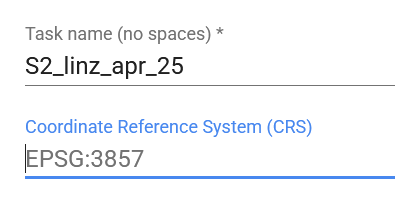

In [57]:
import rasterio

src1 = rasterio.open("/home/jovyan/ideas-dslab-group1-shared/cleaned data/sentinel data/S2_barcelona_apr_25.tif")
print(src1.crs)
src2 = rasterio.open("/home/jovyan/ideas-dslab-group1-shared/cleaned data/sentinel data/S2_hamburg_apr_25.tif")
print(src2.crs)
src3 = rasterio.open("/home/jovyan/ideas-dslab-group1-shared/cleaned data/sentinel data/S2_paris_apr_25.tif")
print(src3.crs)
src4 = rasterio.open("/home/jovyan/ideas-dslab-group1-shared/cleaned data/sentinel data/S2_vienna_apr_25.tif")
print(src4.crs)

EPSG:4326
EPSG:4326
EPSG:4326
EPSG:4326


<blockquote> Good, it was EPSG:4326 and not EPSG:3857<br> The new satellite data for Linz and Innsbruck from 2025 has also been saved to our shared folder.</blockquote>

 ### <center>Image counts by city and month</center>

| City      | Apr | Aug | Oct/Nov |
|-----------|-----|-----|---------|
| Vienna    | 6   | 14  | 8 (Nov) |
| Paris     | 17  | 16  | 3 (Oct) |
| Hamburg   | 6   | 4   | 1 (Nov) |
| Barcelona | 5   | 6   | 7 (Nov) |
| Linz | 5   | 9   | 1 (Oct) <i>(Nov had 0)</i>|
| Innsbruck | 7   | 6   | 6 (Nov) |

## <b>8. Documentation of additional viennese context data</b>

#### <b><u>Ongoing Issue (14.05.2026):</b></u>

Our Vienna tree cadastre dataset only contains publicly managed trees, while private trees remain unknown (=not Ground Truth). <br>Additionally, OpenStreetMap(OSM) is community-driven and therefore spatially incomplete.

<blockquote>To help our model learn the distinction between public and potentially private tree locations, I fetched following fficial datasets from <a href="https://www.data.gv.at/"> https://www.data.gv.at/</a>:</blockquote>

- <b><a href="https://www.data.gv.at/datasets/9e1ad9a0-ff89-3ac2-b4ac-d87f3a2c6554?locale=de">RNK Land Use Data</a></b><i> Official Vienna land-use polygons </i>(json)

- <b><a href="https://www.data.gv.at/datasets/d0145df8-7f6d-46e1-9bc6-ee7897054104?locale=de">Public Green Space Data</a></b><i> Official polygons of <u>publicly</u> accessible green areas in Vienna </i>(json)

- <b><a href="https://www.data.gv.at/datasets/7cf0da04-1f77-4321-929e-78172c74aa0b?locale=de">Vienna Multi-Purpose Map (Vector Data)</a></b><i> Detailed urban surface and infrastructure polygons </i>(gpkg)
<br>

### <b>1. Cleaning and saving RNK Land Use Data:</b>

The dataset presents Vienna's actual land use in a generalized form. A total of 30 land use categories are distinguished, which are assigned to the overarching categories of building land, green space, and transport.

In [5]:
#!pip install geopandas

In [59]:
import geopandas as gpd
#Code = Kodierung der 30 Nutzungskategorien; categories are hierarchically structured in 3 levels
#LEV3 = Beschreibung der 30 Nutzungskategorien; LEV2 = Gliederung in 11 Überkategorien; LEV1 = Gliederung in 3 Überkategorien 
#I will choose level 3=3 groups, its cleaner and simpler for our ml-model
land_use = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/vienna context data/vienna_land_use_data.json")

#convert to projected CRS for austria, then calculate centroid, then convert centroids back to lon and lat
centroids = (land_use.to_crs(epsg=31256).geometry.centroid.to_crs(epsg=4326)) #
land_use["longitude"] = centroids.x  
land_use["latitude"] = centroids.y

land_use = land_use[["LEV1","FLAECHE","longitude","latitude"]] #only columns we need, did manual inspection before
land_use = land_use.rename(columns={"LEV1": "land_use_group","FLAECHE": "area"}) #renaming columns into englisch just in case
#print(land_use.head())

### Translating columns into englisch

In [60]:
print(land_use["land_use_group"].unique())

<ArrowStringArray>
['Baulandnutzung', 'Verkehr', 'Grünlandnutzung']
Length: 3, dtype: str


In [61]:
land_use["land_use_group"] = (land_use["land_use_group"]
    .replace({"Baulandnutzung": "built-up area","Verkehr": "transport","Grünlandnutzung": "green space"}))
print(land_use.head())

  land_use_group          area  longitude   latitude
0  built-up area   8730.050650  16.366452  48.165859
1  built-up area   4475.390170  16.356348  48.198535
2  built-up area    795.973600  16.394764  48.123956
3      transport  50997.731521  16.448732  48.212441
4  built-up area  68894.506399  16.409114  48.273173


### Checking missings, duplicates and datatypes

In [62]:
land_use.duplicated().any() #not geometry column as lists are unhashable :o

np.False_

In [63]:
land_use.isnull().sum() #nice no missings

land_use_group    0
area              0
longitude         0
latitude          0
dtype: int64

In [64]:
print(land_use.info())

<class 'pandas.DataFrame'>
RangeIndex: 19513 entries, 0 to 19512
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   land_use_group  19513 non-null  str    
 1   area            19513 non-null  float64
 2   longitude       19513 non-null  float64
 3   latitude        19513 non-null  float64
dtypes: float64(3), str(1)
memory usage: 842.6 KB
None


<blockquote>Our datatypes are already correct</blockquote>

### Saving data

In [65]:
land_use.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/vienna context data/vienna_land_use_data.parquet")

### <b>2. Cleaning and saving Public Green Space Data:</b>

"T_TEXT" = green space<br>
"P_WLD" = forest<br>
"P_WAS" = water<br>
P_PK" = park<br>
"Q_SPI" = playground<br>
"Q_HUN" = dog zone<br>
"Q_SPO" = sport areas<br>

In [66]:
green_space = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/vienna context data/vienna_green_space_data.json")

#convert to projected CRS for austria, then calculate centroid, then convert centroids back to lon and lat
centroids = (green_space.to_crs(epsg=31256).geometry.centroid.to_crs(epsg=4326)) #
green_space["longitude"] = centroids.x 
green_space["latitude"] = centroids.y

#again after manual inspection I think these columns are the most intresting for the ml model
green_space = green_space[["FLAECHE","P_WLD","P_WAS","P_PK","Q_SPI", "Q_HUN", "Q_SPO", "longitude", "latitude"]]
green_space = green_space.rename(columns={"FLAECHE": "area","P_WLD": "forest",
    "P_WAS": "water","P_PK": "park","Q_SPI": "playground","Q_HUN": "dog_zone","Q_SPO": "sports"})

#easier for our ml gain to convert everything into boolean and we dont care about the count
#sport e.g. was 1245, I checked the infos and i guess those are counts
flag_cols=["forest","water","park","playground","dog_zone","sports"]
green_space[flag_cols] = green_space[flag_cols] > 0

print(green_space.head())

           area  forest  water   park  playground  dog_zone  sports  \
0  57020.131903   False  False   True        True      True    True   
1   2002.715993   False  False  False       False     False   False   
2   3243.484789   False  False   True       False      True    True   
3   5086.636435   False  False   True        True     False   False   
4   4592.970400   False  False   True        True     False    True   

   longitude   latitude  
0  16.348832  48.232251  
1  16.328062  48.234918  
2  16.308693  48.223016  
3  16.303670  48.229175  
4  16.335086  48.226752  


### Checking missings, duplicates and datatypes

In [67]:
green_space.duplicated().any() #not geometry column as lists are unhashable :o

np.False_

In [68]:
green_space.isnull().sum() #nice no missings

area          0
forest        0
water         0
park          0
playground    0
dog_zone      0
sports        0
longitude     0
latitude      0
dtype: int64

In [69]:
print(green_space.info())

<class 'pandas.DataFrame'>
RangeIndex: 1936 entries, 0 to 1935
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        1936 non-null   float64
 1   forest      1936 non-null   bool   
 2   water       1936 non-null   bool   
 3   park        1936 non-null   bool   
 4   playground  1936 non-null   bool   
 5   dog_zone    1936 non-null   bool   
 6   sports      1936 non-null   bool   
 7   longitude   1936 non-null   float64
 8   latitude    1936 non-null   float64
dtypes: bool(6), float64(3)
memory usage: 56.8 KB
None


<blockquote>Those datatypes are also already correct</blockquote>

### Saving data

In [70]:
green_space.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/vienna context data/vienna_green_space_data.parquet")

#### <b>1. Cleaning and saving Vienna Multi-Purpose Map (Vector Data):</b>

In [83]:
#got an invalid geometry error :c
#https://geopandas.org/en/latest/docs/reference/api/geopandas.GeoSeries.from_wkb.html
vienna_multi = gpd.read_file(
    "/home/jovyan/ideas-dslab-group1-shared/raw data/vienna context data/vienna_multi_map_data.gpkg",
    engine="pyogrio", on_invalid="ignore")

#print(vienna_multi.info())
vienna_multi = vienna_multi.set_crs(epsg=31256, allow_override=True) #get lat and lon agian and convert just in case
centroids = vienna_multi.geometry.centroid.to_crs(epsg=4326)
vienna_multi["longitude"] = centroids.x
vienna_multi["latitude"] = centroids.y

vienna_multi = vienna_multi[["F_KLASSE_TEXT","GEWAESSER","longitude","latitude"]]
vienna_multi = vienna_multi.rename(columns={"F_KLASSE_TEXT": "feature_type","GEWAESSER": "water"})
print(vienna_multi.head())

       feature_type  water  longitude   latitude
0  Ruhender Verkehr    0.0  16.419616  48.171000
1           Gebäude    0.0  16.322595  48.206857
2          Flugdach    0.0  16.371931  48.185034
3           Gebäude    0.0  16.322029  48.206960
4  Ruhender Verkehr    0.0  16.439911  48.247550


### Checking missings, duplicates and datatypes

In [84]:
vienna_multi.duplicated().any() #not geometry column as lists are unhashable :o

np.True_

In [85]:
duplicates = vienna_multi[vienna_multi.duplicated()]
print(duplicates.head())
print(vienna_multi.duplicated().sum())

             feature_type  water  longitude   latitude
31126   Befestigte Fläche    0.0  16.288439  48.193093
84042   Befestigte Fläche    0.0  16.448625  48.160113
138210     Straßenmobilar    0.0  16.355275  48.200209
138211     Straßenmobilar    0.0  16.355603  48.200319
155110  Sonstiges Bauwerk    0.0  16.362986  48.191580
31


In [86]:
#vienna_multi.count()
vienna_multi = vienna_multi.drop_duplicates()

<blockquote>31 duplicates out of 2.7 million rows is tiny, so we will drop them nd classify them as MCAR.</blockquote>

In [88]:
vienna_multi.isnull().sum()

feature_type     0
water           26
longitude        1
latitude         1
dtype: int64

In [89]:
vienna_multi = vienna_multi.dropna()
vienna_multi.isnull().sum()

feature_type    0
water           0
longitude       0
latitude        0
dtype: int64

In [91]:
print(vienna_multi.info())

<class 'pandas.DataFrame'>
Index: 2715457 entries, 0 to 2715514
Data columns (total 4 columns):
 #   Column        Dtype  
---  ------        -----  
 0   feature_type  str    
 1   water         float64
 2   longitude     float64
 3   latitude      float64
dtypes: float64(3), str(1)
memory usage: 131.5 MB
None


<blockquote>Those datatypes are correct</blockquote>

In [96]:
#and again translate just in case
#print(vienna_multi["feature_type"].unique())
translation = {"Ruhender Verkehr": "Parking area","Gebäude": "Building","Flugdach": "Canopy",
    "Befestigte Fläche": "Paved area","Gehweg, Radweg": "Walkway/Cycle path",
    "Grünfläche": "Green space","Wiese": "Meadow","Mauer": "Wall",
    "Gehsteig": "Sidewalk","Stiege": "Stairs","Private Verkehrsfläche": "Private road",
    "Verkehrsinsel": "Traffic island","Zebrastreifen": "Crosswalk","Fahrbahn": "Roadway",
    "Fußgängerzone": "Pedestrian zone","Wald": "Forest","Natürliches Gewässer": "Natural water body",
    "Weingarten": "Vineyard","Sportfeld": "Sports field","Baustelle": "Construction site",
    "Feld, Acker": "Agricultural field","Brunnen": "Fountain","Denkmal": "Monument","Kiosk": "Kiosk"}

vienna_multi["feature_type"] = (vienna_multi["feature_type"].replace(translation))
#print(vienna_multi.head())

### Saving data


In [98]:
vienna_multi.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/vienna context data/vienna_multi_map_data.parquet")

### <b><center>Overview of Viennese Context Data</center></b>

<code>land_use.parquet</code>: Generalized land-use information for Vienna.

| Column | Description |
|---|---|
| `land_use_group` | 3 land-use category |
| `area` | Polygon area in m² |
| `longitude` | Longitude of centroid |
| `latitude` | Latitude of centroid |


---

<code>green_space.parquet</code>: Publicly accessible green spaces and recreational areas in Vienna.

| Column | Description |
|---|---|
| `area` | Area in m² |
| `forest` | Forest flag |
| `water` | Water flag |
| `park` | Park flag |
| `playground` | Playground flag |
| `dog_zone` | Dog zone flag |
| `sports` | Sports facility flag |
| `longitude` | Longitude |
| `latitude` | Latitude |

---

<code>vienna_multi_map.parquet</code>: Detailed urban infrastructure and surface object data.

| Column | Description |
|---|---|
| `feature_type` | Urban feature category |
| `water` | Water-related flag |
| `longitude` | Longitude |
| `latitude` | Latitude |

<blockquote>
<b>A EDA notebook from my colleague will follow to provide statistical proof and further data cleaning, in case I missed something.</b>
</blockquote>